# 07_persistence_send_subgraph

对应 `index.md` 第 7 阶段：`SqliteSaver` / Postgres 落盘、`Send` fanout、子图、durable execution。

笔记本在 `codes/langgraph/07_persistence_send_subgraph/qa.ipynb`。需要读写文件时，工作空间就是这个目录。

先运行下一格，得到 `ROOT` 并加载 `codes/langgraph/local.env`。每题只改 `# 作答` 下面的代码。前置代码不用改。做完自己跑通即可，先不要对答案。

前六个阶段一直在 `MemorySaver` 上练：进程一退 state 就没了，`get_state_history` 也只是内存里的一条链。这一阶段换成真落盘，并把图从「一条流水线」扩成「一张派发再汇总的网」：

| 主题 | 一句话 |
| --- | --- |
| `SqliteSaver` | checkpoint 写进 SQLite 文件；换连接、换进程都还在 |
| `Send` | 条件边的 router 返回 `Send` 列表 → 一次派发多个并行分支（map），结果靠 reducer 汇总（reduce） |
| 子图 | 编译好的图可以直接当节点用，`xray=True` 时才露出它内部的节点 |
| durable execution | 节点中途报错，checkpoint 停在原地；`invoke(None, config)` 从那里接着跑 |

**版本**：这一阶段新装了 `langgraph-checkpoint-sqlite`，`SqliteSaver` 在 `langgraph.checkpoint.sqlite` 里（和 `langgraph.checkpoint.memory` 不是一个地方）。Postgres 那条路（`langgraph-checkpoint-postgres` 的 `PostgresSaver` / `AsyncPostgresSaver`）接口一致，但要真数据库，本机没装也不起服务，只在第 2 题末尾当对照提一句，不实连。

`_runs/` 是本阶段的运行目录（放 sqlite 文件和标记文件），落在 `.gitignore` 的 `codes/langgraph/*/*/` 覆盖范围内。第 1 题起都要调 API。


In [1]:
import os
from pathlib import Path

def lab_root() -> Path:
    """qa.ipynb 所在目录。"""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if folder.name == "07_persistence_send_subgraph" and (folder / "qa.ipynb").is_file():
            return folder
        candidate = folder / "codes" / "langgraph" / "07_persistence_send_subgraph"
        if (candidate / "qa.ipynb").is_file():
            return candidate
    return here

def load_local_env(env_path: Path) -> None:
    """把 local.env 写入 os.environ（已有键不覆盖）。"""
    if not env_path.is_file():
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        value = value.strip().strip("\"'")
        if key and key not in os.environ:
            os.environ[key] = value

ROOT = lab_root()
load_local_env(ROOT.parent / "local.env")
RUNS = ROOT / "_runs"
RUNS.mkdir(exist_ok=True)
ROOT, RUNS, bool(os.environ.get("DEEPSEEK_API_KEY"))


(PosixPath('/Users/keyficller/Documents/AEFS-Notes/codes/langgraph/07_persistence_send_subgraph'),
 PosixPath('/Users/keyficller/Documents/AEFS-Notes/codes/langgraph/07_persistence_send_subgraph/_runs'),
 True)

## 1. `SqliteSaver`：把 checkpoint 写进文件

`MemorySaver` 只活在内存里。换成 `SqliteSaver`，checkpoint 会落进一个 SQLite 文件，连接关掉、进程退出都不影响。

有一个必须先认清的点：`SqliteSaver.from_conn_string("...")` **返回的是上下文管理器，不是 saver**。要在 `with` 里取到真正能用的 saver，而且整个使用期（`compile` 之后所有 `invoke`）都得待在这个 `with` 里——连接一关它就不能用了。把 `from_conn_string(...)` 直接塞给 `compile` 会 `TypeError: Invalid checkpointer provided ... Received _GeneratorContextManager`。

已有 `model`、节点 `agent`、建好的 `graph`（还没 compile，`START → agent → END`），以及 `DB = RUNS / "q1.sqlite"`（前置代码已把旧文件删掉，保证这次是干净的）和 `config`（`thread_id = "sqlite-1"`）。

1. `from langgraph.checkpoint.sqlite import SqliteSaver`，在 `with SqliteSaver.from_conn_string(str(DB)) as saver:` 里面 `compile(checkpointer=saver)`
2. 用同一个 `config` 连跑两次：先 `HumanMessage("我叫小明。")`，再**只传** `HumanMessage("我叫什么？")`
3. 打印两次返回的消息条数，以及第二次最后一条的 `content`
4. 退出 `with` 之后，打印 `DB.is_file()` 和 `DB.stat().st_size`，确认文件真的写出来了

预期第 3 步是 2 和 4，第二次能答出名字——历史和 `MemorySaver` 那题一样是自动接上的，区别只在它现在躺在磁盘上。想重测就先重跑这一格的前置代码（它删文件），否则旧 checkpoint 会让条数接着往上长。


In [4]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

DB = RUNS / "q1.sqlite"
DB.unlink(missing_ok=True)
config = {"configurable": {"thread_id": "sqlite-1"}}

def agent(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"])]}

graph = StateGraph(MessagesState)
graph.add_node("agent", agent)
graph.add_edge(START, "agent")
graph.add_edge("agent", END)

# 作答

from langgraph.checkpoint.sqlite import SqliteSaver

config = {
    "configurable": {
        "thread_id": "sqlite-1"
    }
}

with SqliteSaver.from_conn_string(str(DB)) as saver:
    app = graph.compile(checkpointer=saver)

    response = app.invoke(
        {"messages": [HumanMessage("我叫小明。")]},
        config
    )

    print(len(response["messages"]))
    response["messages"][-1].pretty_print()

    response = app.invoke(
        {"messages": [HumanMessage("我叫什么？")]},
        config
    )

    print(len(response["messages"]))
    response["messages"][-1].pretty_print()

print(DB.is_file())
print(DB.stat().st_size)
    

#评阅
# 对。四步都做到：在 `with ... as saver` 里 compile、同一个 config 连跑两次、2 条 → 4 条且答出「你叫小明」，
# 退出 with 后 is_file() / st_size 也都是真值（36864）。
# 两点小注：① 前置代码已经给过 config，作答里又原样写了一遍，能跑但多余；
# ② pretty_print() 输出好看，但标题是 "Ai Message" 这种给人看的写法，不是类名；要按类名判断仍用 type(m).__name__。

#参考答案
# from langgraph.checkpoint.sqlite import SqliteSaver
#
# with SqliteSaver.from_conn_string(str(DB)) as saver:
#     app = graph.compile(checkpointer=saver)
#     r1 = app.invoke({"messages": [HumanMessage("我叫小明。")]}, config)
#     print(len(r1["messages"]))                                  # 2
#     r2 = app.invoke({"messages": [HumanMessage("我叫什么？")]}, config)
#     print(len(r2["messages"]), r2["messages"][-1].content)      # 4 你叫小明
#
# print(DB.is_file(), DB.stat().st_size)


2
================================== Ai Message ==================================

你好，小明！很高兴认识你。有什么我可以帮你的吗？
4
================================== Ai Message ==================================

你叫小明呀。
True
36864


## 2. 关掉连接、换新连接：证明它是真的持久

上一题只证明「写进文件」了。这一题证明它**持久**：把 `with` 整个退出，新开一个 `SqliteSaver`，重新 `compile` 出一个**全新的 app 对象**，同一个 `thread_id` 的历史依然在。

已有 `model`、`agent`、`graph`、`DB = RUNS / "q2.sqlite"`（前置已删旧文件），以及两个线程 id：`thread_sqlite = "persist-sqlite"`、`thread_mem = "persist-mem"`。

1. 第一个 `with`：跑第一轮（`HumanMessage("我叫小明。")`），打印消息条数，然后**退出 with**
2. 第二个 `with`（新 saver、新 compile 出的 app 对象）：先用 `app.get_state(config)` 读一下历史，打印条数；再**只传** `HumanMessage("我叫什么？")` 续跑，打印条数和最后一条 `content`
3. 对照实验用 `MemorySaver`：第一次 `compile(checkpointer=MemorySaver())` 跑一轮；然后**再新建一个** `MemorySaver`、重新 compile，用同一个 `thread_mem` 只传第二问，打印条数和 `content`
4. 对照 2 和 3 的数字，说清楚差别在哪

第 3 步两轮用的是同一个 `thread_id`，但两个 `MemorySaver` 实例之间不共享任何东西；`SqliteSaver` 那组能接上，靠的是文件。

（Postgres 那条路换的是 `langgraph-checkpoint-postgres` 的 `PostgresSaver` / `AsyncPostgresSaver` 加一个连接串，其余写法不变；本机没有 Postgres 服务，这里不实连。）


In [9]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

DB = RUNS / "q2.sqlite"
DB.unlink(missing_ok=True)
thread_sqlite = "persist-sqlite"
thread_mem = "persist-mem"

def agent(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"])]}

graph = StateGraph(MessagesState)
graph.add_node("agent", agent)
graph.add_edge(START, "agent")
graph.add_edge("agent", END)

# 作答

from langgraph.checkpoint.sqlite import SqliteSaver

configs = {
    thread : {
        "configurable": {
            "thread_id": thread
        }
    }
    for thread in [thread_sqlite, thread_mem]
}

with SqliteSaver.from_conn_string(str(DB)) as saver:
    app = graph.compile(checkpointer=saver)

    response = app.invoke(
        {"messages": [HumanMessage("我叫小明。")]},
        configs[thread_sqlite]
    )

    print(len(response["messages"]))

with SqliteSaver.from_conn_string(str(DB)) as saver:
    app = graph.compile(checkpointer=saver)

    app.get_state(configs[thread_sqlite])

    response = app.invoke(
        {"messages": [HumanMessage("我叫什么？")]},
        configs[thread_sqlite]
    )

    print(len(response["messages"]))
    response["messages"][-1].pretty_print()
    
## --------- Test MemorySaver -----------------

from langgraph.checkpoint.memory import MemorySaver

app = graph.compile(checkpointer=MemorySaver())

response = app.invoke(
    {"messages": [HumanMessage("我叫小明。")]},
    config
)

app = graph.compile(checkpointer=MemorySaver())

response = app.invoke(
    {"messages": [HumanMessage("我叫什么？")]},
    config
)

print(len(response["messages"]))
response["messages"][-1].pretty_print()

# If you want to persist through different session, use file saver as database like SqliteSaver.

#评阅
# 主体对，两组的对照结论也拿到了：sqlite 那组第一轮 2 条 → 关掉 with → 新 saver + 新 compile → 续跑到 4 条答出名字；
# MemorySaver 那组换新实例后只有 2 条、答不出名字（打印出来「我不知道你叫什么名字」），正好是你末尾那句注释说的事。
# 一处要改：MemorySaver 那两轮传的是 `config`，但这个变量在本格并没有定义——它来自第 1 题的全局
# thread_id="sqlite-1"。这次不影响结论（换了新 saver，本来就没有历史），但等于在复用第 1 题的线程 id，
# 属于「用了没定义的变量」。应写 configs[thread_mem]。
# 一处没做：第 2 步要求「先打印 get_state 读回的条数」，你只调了 app.get_state(...) 没打印。
# 小点：configs 那个字典推导对两个固定线程略绕，直接写 cfg_s / cfg_m 更直白（和第 3、4 阶段同一处小习惯）。

#参考答案
# cfg_s = configs[thread_sqlite]
# cfg_m = configs[thread_mem]
#
# with SqliteSaver.from_conn_string(str(DB)) as saver:
#     app = graph.compile(checkpointer=saver)
#     r = app.invoke({"messages": [HumanMessage("我叫小明。")]}, cfg_s)
#     print(len(r["messages"]))                                   # 2
#
# with SqliteSaver.from_conn_string(str(DB)) as saver:            # 换新连接
#     app = graph.compile(checkpointer=saver)                     # 换新 app 对象
#     print("读回:", len(app.get_state(cfg_s).values["messages"])) # 2
#     r = app.invoke({"messages": [HumanMessage("我叫什么？")]}, cfg_s)
#     print(len(r["messages"]), r["messages"][-1].content)        # 4 你叫小明
#
# mem1 = graph.compile(checkpointer=MemorySaver())
# print(len(mem1.invoke({"messages": [HumanMessage("我叫小明。")]}, cfg_m)["messages"]))
# mem2 = graph.compile(checkpointer=MemorySaver())                # 换新实例
# rm = mem2.invoke({"messages": [HumanMessage("我叫什么？")]}, cfg_m)
# print(len(rm["messages"]), rm["messages"][-1].content)          # 2 答不出名字


2
4
================================== Ai Message ==================================

你叫小明。
2
================================== Ai Message ==================================

我不知道你叫什么名字。你还没有告诉我。你可以告诉我你的名字，我会这样称呼你。


## 3. `Send`：一次派发多条分支（map）

条件边的 router 以前只返回**一个**目的地。返回 `Send` 列表就能一次派发多个分支，每个分支带自己的一份小 state——这是 LangGraph 的 map 半步。

已有 State `Fan`（`topics: list[str]` 是输入、`lines: Annotated[list[str], operator.add]` 是汇总）、节点 `write_line(payload)`（读 `payload["topic"]`，返回 `{"lines": [f"[{payload['topic']}]"]}`），以及只注册了节点的 `graph`（还没连边）。

1. 写 router `dispatch(state)`：对 `state["topics"]` 里每个主题返回一个 `Send("write_line", {"topic": 主题})`（`Send` 在 `langgraph.types` 里，自己 import）
2. 用 `add_conditional_edges(START, dispatch, ["write_line"])` 连边——第三个参数这次给的是**节点名列表**，不是 dict，因为目的地已经写在每个 `Send` 里了
3. `write_line` 接静态边到 `END`；`compile` 后 `invoke({"topics": ["缓存", "限流", "重试"]})`
4. 打印 `lines` 的长度，以及排序后的内容
5. 把 `topics` 换成 5 个主题再跑一次，看 `lines` 的顺序是不是和输入顺序一致；多跑几遍。并行分支的写入顺序**不保证**，这次碰巧同序不代表下次也同序

两个要点：`Send` 的第二个参数是**这个分支自己的 state**，不是父图整份 state——`write_line` 里拿得到 `topic`，拿不到 `topics` / `lines`。另外多个分支往同一个键写时，那个键**必须是 reducer**（这里 `lines` 是 `operator.add`），否则会 `InvalidUpdateError: At key '...': Can receive only one value per step.`


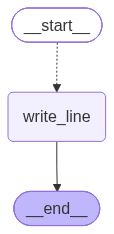

3
[缓存]
[重试]
[限流]
[缓存], [限流], [重试], [爆炸], [成功]


In [21]:
import operator
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph
import time

class Fan(TypedDict):
    topics: list[str]
    lines: Annotated[list[str], operator.add]

def write_line(payload: dict) -> dict:
    return {"lines": [f"[{payload['topic']}]"]}

graph = StateGraph(Fan)
graph.add_node("write_line", write_line)

# 作答

from langgraph.types import Send

def dispatch(state: Fan) -> list[Send]:
    return [Send("write_line", {"topic": topic}) for topic in state["topics"]]

graph.add_conditional_edges(START, dispatch, ["write_line"])

graph.add_edge("write_line", END)

app = graph.compile()

from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

lines = app.invoke({"topics": ["缓存", "限流", "重试"]})["lines"]

print(len(lines))

for line in sorted(lines):
    print(line)


lines = app.invoke({"topics": ["缓存", "限流", "重试", "爆炸", "成功"]})["lines"]

print(", ".join(lines))



#评阅
# 对。dispatch 返回 list[Send]、add_conditional_edges(START, dispatch, ["write_line"]) 用节点名列表、
# write_line → END，3 条并行都写进 lines，排序后 [缓存] [重试] [限流]；5 个主题那轮也跑通。
# 一部要点：那轮打印出来是输入顺序，但**并行分支的写入顺序不保证**，换数据、多跑几遍可能不同序。
# 要顺序稳定就别依赖它——给每条结果带上 index 再排序，或让下游按 key 对齐，不要靠 reducer 的先后。
# 小点：import time 没用上；draw_mermaid_png() 要联网下载（离线会失败），只想看结构用 draw_mermaid() 出文本更稳。

#参考答案
# from langgraph.types import Send
#
# def dispatch(state: Fan):
#     return [Send("write_line", {"topic": t}) for t in state["topics"]]
#
# graph.add_conditional_edges(START, dispatch, ["write_line"])
# graph.add_edge("write_line", END)
# app = graph.compile()
#
# out = app.invoke({"topics": ["缓存", "限流", "重试"]})
# print(len(out["lines"]), sorted(out["lines"]))       # 3 ['[limiting]' ...]
# out = app.invoke({"topics": list("abcde")})
# print(out["lines"], sorted(out["lines"]))            # 5 条，顺序不保证


## 4. 子图当节点：把一条流水线打包成一块积木

`compile()` 出来的图本身就是可调用对象，所以它能**直接当另一个图的节点**。这一题先把一条两句的流水线做出来，再把它塞进父图，看 `xray` 里长什么样。

已有 State `Doc`（`text: str`）、节点 `draft`（前缀加 `草稿：`）和 `polish`（后缀加 `！`），以及只 `add_node` 了 `draft` / `polish`、还没连边的 `sg`。

1. 把 `sg` 连成 `START → draft → polish → END`，`compile()` 成 `sub`
2. 新建父图 `pg = StateGraph(Doc)`，把 `sub` 当成节点挂上去（节点名 `"pipeline"`），连 `START → pipeline → END`，`compile()` 成 `app`
3. `invoke({"text": "LangGraph"})`，打印最终 `text`
4. 打印 `sorted(sub.get_graph().nodes.keys())`、`sorted(app.get_graph().nodes.keys())`，再用 `app.get_graph(xray=True)` 打印一次。对比后两次的输出，看子图内部的节点是怎么露出来的

第 4 步是重点：不 xray 时父图只看到 `pipeline` 一个盒子；`xray=True` 才会把 `pipeline:draft` 这种展开的节点名给出来。

子图当节点有个前提：父图和子图的 state **键要能对上**（这里都是 `text`）。子图返回的键如果父图 schema 里没有，会被丢掉——不是报错，是静默消失。


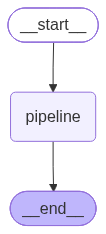

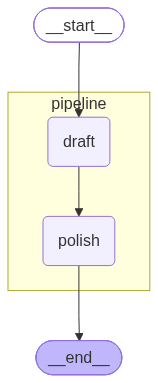

草稿：LangGraph！


In [25]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

class Doc(TypedDict):
    text: str

def draft(state: Doc) -> dict:
    return {"text": "草稿：" + state["text"]}

def polish(state: Doc) -> dict:
    return {"text": state["text"] + "！"}

sg = StateGraph(Doc)
sg.add_node("draft", draft)
sg.add_node("polish", polish)

# 作答

sg.add_edge(START, "draft")
sg.add_edge("draft", "polish")
sg.add_edge("polish", END)

sub = sg.compile()

pg = StateGraph(Doc)

pg.add_node("pipeline", sub)
pg.add_edge(START, "pipeline")
pg.add_edge("pipeline", END)

app = pg.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

reponse = app.invoke(
    {"text": "LangGraph"}
)

print(reponse["text"])




#评阅
# 对。三条静态边连对、sub = sg.compile()、父图把 sub 挂成节点 "pipeline"、invoke 出「草稿：LangGraph！」。
# 第 4 步只画了 mermaid，没打节点名列表。xray 图里确实能看到 pipeline:draft / pipeline:polish，
# 但结论要对照「父图只看到 pipeline 一个盒子」，用 nodes.keys() 打出来更直接，也不依赖联网画图：
#   sorted(sub.get_graph().nodes.keys())          -> ['__end__', '__start__', 'draft', 'polish']
#   sorted(app.get_graph().nodes.keys())          -> ['__end__', '__start__', 'pipeline']
#   sorted(app.get_graph(xray=True).nodes.keys()) -> ['__end__', '__start__', 'pipeline:draft', 'pipeline:polish']
# 小点：变量拼成 reponse（response）；两张图参数只差 xray=True，并排看可以，但不如把上面三行打出来对比。

#参考答案
# sg.add_edge(START, "draft")
# sg.add_edge("draft", "polish")
# sg.add_edge("polish", END)
# sub = sg.compile()
#
# pg = StateGraph(Doc)
# pg.add_node("pipeline", sub)
# pg.add_edge(START, "pipeline")
# pg.add_edge("pipeline", END)
# app = pg.compile()
#
# print(app.invoke({"text": "LangGraph"})["text"])             # 草稿：LangGraph！
# print(sorted(sub.get_graph().nodes.keys()))
# print(sorted(app.get_graph().nodes.keys()))
# print(sorted(app.get_graph(xray=True).nodes.keys()))


## 5. durable execution：节点炸了，从 checkpoint 接着跑

checkpoint 不只记历史，它让「跑挂了」变成「可以接着跑」。这一题故意让中间那个节点第一次抛错，看 checkpoint 停在哪儿，再从那里续上。

已有 State `Job`（`value: int`）、三个节点 `step_a`（+1）、`flaky`（第一次抛 `RuntimeError`，之后 +10）、`step_c`（×2），以及 `DB = RUNS / "q5.sqlite"`、`MARK = RUNS / "q5.marker"`（前置都删干净了）和 `config`（`thread_id = "durable-1"`）。`flaky` 就是靠 `MARK` 这个标记文件判断自己是不是第一次跑。

1. 在 `with SqliteSaver.from_conn_string(str(DB)) as saver:` 里 `compile(checkpointer=saver)`
2. 把第一次 `invoke({"value": 1}, config)` 包在 `try/except` 里，打印异常类型和消息
3. 打印 `app.get_state(config).next` 和 `.values["value"]`：确认 checkpoint 停在**哪个节点前**，已经写进去的值是多少——想清楚为什么是 2，不是 1，也不是 11
4. 再 `app.invoke(None, config)` 续跑，打印返回的 `value`，以及跑完后的 `next`
5. 打印 `len(list(app.get_state_history(config)))`，和第 3 阶段那条内存里的链对照

关键：抛错那一步**没有被写进 checkpoint**，所以续跑时 `flaky` 会**重跑一遍**。这也是为什么节点里的外部副作用要幂等——和第 4 阶段 `Command(resume=...)` 让节点重跑是同一个道理。


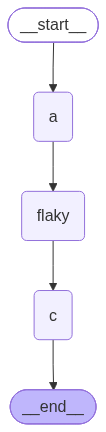

RuntimeError 第一次故意失败
('flaky',)
2
()
24
------------------------------------------------------------
5
()
24
('c',)
12
('flaky',)
2
('a',)
1
('__start__',)
no value


In [39]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

DB = RUNS / "q5.sqlite"
DB.unlink(missing_ok=True)
MARK = RUNS / "q5.marker"
MARK.unlink(missing_ok=True)
config = {"configurable": {"thread_id": "durable-1"}}

class Job(TypedDict):
    value: int

def step_a(state: Job) -> dict:
    return {"value": state["value"] + 1}

def flaky(state: Job) -> dict:
    if not MARK.exists():
        MARK.write_text("tried")
        raise RuntimeError("第一次故意失败")
    return {"value": state["value"] + 10}

def step_c(state: Job) -> dict:
    return {"value": state["value"] * 2}

graph = StateGraph(Job)
graph.add_node("a", step_a)
graph.add_node("flaky", flaky)
graph.add_node("c", step_c)
graph.add_edge(START, "a")
graph.add_edge("a", "flaky")
graph.add_edge("flaky", "c")
graph.add_edge("c", END)

# 作答

from langgraph.checkpoint.sqlite import SqliteSaver
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

config = {
    "configurable": {
        "thread_id": "durable-1"
    }
}

with SqliteSaver.from_conn_string(str(DB)) as saver:
    app = graph.compile(checkpointer=saver)
    
    try:
        response = app.invoke(
            {"value": 1},
            config
        )

    except Exception as e:
        print(type(e).__name__, e)

    print(app.get_state(config).next)
    print(app.get_state(config).values["value"])

    response = app.invoke(
        None,
        config
    )

    if "messages" in response:
        for m in response["messages"]:
            m.pretty_print()

    print(app.get_state(config).next)
    print(app.get_state(config).values["value"])

    print("---" * 20)
    print(len(list(app.get_state_history(config))))
    for snap in app.get_state_history(config):
        print(snap.next)
        print(snap.values["value"] if "value" in snap.values else "no value")


#评阅
# 全做对，而且比题目多做了：异常类型/消息、next == ('flaky',)、值 2（不是 1 也不是 11）、续跑后 () / 24、
# 快照 5 条，还把每个快照的 next 与值都列了出来——最后那串输出正好证明「抛错那一步没写进 checkpoint」，
# 所以续跑时 flaky 会重跑一遍。这一点抓得准。
# 一处小问题：本格开头那句 display(Image(app.get_graph(xray=True)...)) 在 app = graph.compile(...) **之前**，
# 此时 app 还是第 4 题的父图，显示出来的不是本题的图。要么挪到 with 里 compile 之后，要么删掉。
# 另一处：if "messages" in response: 那段对 Job 永远不成立（state 里只有 value），是死分支。

#参考答案
# from langgraph.checkpoint.sqlite import SqliteSaver
#
# with SqliteSaver.from_conn_string(str(DB)) as saver:
#     app = graph.compile(checkpointer=saver)
#     try:
#         app.invoke({"value": 1}, config)
#     except Exception as e:
#         print(type(e).__name__, e)                            # RuntimeError 第一次故意失败
#
#     snap = app.get_state(config)
#     print(snap.next, snap.values["value"])                    # ('flaky',) 2
#
#     out = app.invoke(None, config)
#     print(out["value"], app.get_state(config).next)            # 24 ()
#     print(len(list(app.get_state_history(config))))            # 5


## 6. 综合：fanout 到子图，结果落盘

把这一阶段的三样东西接成一条链：`Send` 派发多个主题并行写，写的那一段是**真的调模型的子图**，最后汇总成一段。全程 `SqliteSaver`，换新连接后历史还能读回来。

已有：

- `model`
- 子图 `section`（已 compile）：State 是 `Section`（`topic: str`、`lines: Annotated[list[str], operator.add]`），里面一个节点 `write_line` 调模型，针对 `topic` 写**一句**中文，返回 `{"lines": [那句话]}`
- 父图 State `Report`（`topics: list[str]`、`lines: Annotated[list[str], operator.add]`）
- 汇总节点 `summary`：把 `state["lines"]` 交给模型合成一段连贯的话写回 `lines`
- 父图 `graph` 已经 `add_node` 了 `section` 和 `summary`，**还没连边**
- `DB = RUNS / "q6.sqlite"`（前置已删旧文件）和 `config`（`thread_id = "report-1"`）

1. router `dispatch(state)`：对每个 topic 返回 `Send("section", {"topic": 主题})`
2. 连边：`add_conditional_edges(START, dispatch, ["section"])`；`section` 静态边到 `summary`；`summary` 到 `END`
3. 在 `with SqliteSaver.from_conn_string(str(DB)) as saver:` 里 compile，然后 `invoke({"topics": ["缓存", "限流", "重试"]}, config)`
4. 打印 `len(lines)` 和 `lines[-1]`（最后一条是汇总那段）
5. 退出 `with`，**换一个新连接**重新 compile，用同一个 `config` 调 `app.get_state`，打印 `len(snap.values["lines"])` 和最后一条。这一步不该再调模型——历史是从文件里读回来的

第 3 步 `summary` 只跑**一次**（等三条分支都写完才触发），它看到的 `lines` 已经含三条要点，所以最终 `lines` 是 4 条。第 5 步是本阶段的收束：图、fanout、子图、落盘四件事在同一条链上跑通，而且第二次打开文件时并没有重跑。


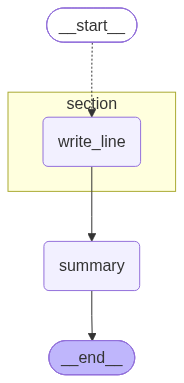

4
加速数据读取并降低数据库与后端负载，控制请求速率以防服务过载崩溃，重试则可缓解瞬时故障、提升请求成功率。


In [ ]:
import operator
from typing import Annotated, TypedDict

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

DB = RUNS / "q6.sqlite"
DB.unlink(missing_ok=True)
config = {"configurable": {"thread_id": "report-1"}}

class Section(TypedDict):
    topic: str
    lines: Annotated[list[str], operator.add]

def write_line(state: Section) -> dict:
    reply = model.invoke(
        f"用一句中文（不超过 20 字）说明「{state['topic']}」在服务端的作用，不要客套话。"
    )
    return {"lines": [reply.content]}

sg = StateGraph(Section)
sg.add_node("write_line", write_line)
sg.add_edge(START, "write_line")
sg.add_edge("write_line", END)
section = sg.compile()

class Report(TypedDict):
    topics: list[str]
    lines: Annotated[list[str], operator.add]

def summary(state: Report) -> dict:
    joined = "\n".join(f"- {line}" for line in state["lines"])
    reply = model.invoke(f"把下面几条要点合成一段连贯的中文，不超过 80 字：\n{joined}")
    return {"lines": [reply.content]}

graph = StateGraph(Report)
graph.add_node("section", section)
graph.add_node("summary", summary)

# 作答

from langgraph.types import Send
from IPython.display import Image, display

def dispatch(state: Report) -> list[Send]:
    return [
        Send("section", {"topic": topic})
        for topic in state["topics"]
    ]

graph.add_conditional_edges(START, dispatch, ["section"])
graph.add_edge("section", "summary")
graph.add_edge("summary", END)

from langgraph.checkpoint.sqlite import SqliteSaver

with SqliteSaver.from_conn_string(str(DB)) as saver:
    app = graph.compile(checkpointer=saver)

    display(Image(app.get_graph(xray=True).draw_mermaid_png()))

    response = app.invoke(
        {"topics": ["缓存", "限流", "重试"]},
        config
    )

    print(len(response["lines"]))
    print(response["lines"][-1])

with SqliteSaver.from_conn_string(str(DB)) as saver:
    app = graph.compile(checkpointer=saver)

    snap = app.get_state(config)

    print(len(snap.values["lines"]))
    print(snap.values["lines"][-1])
    
    

#评阅
# 对。Send 派发到真调模型的子图、section → summary → END、SqliteSaver 落盘，3 条要点 + 1 段汇总 = 4 条；
# 关掉连接换新 saver 重新 compile 后，get_state 读回同样 4 条且最后一条一致——这一步没有重跑模型，正是 durable 的收尾。
# 一点补强：第 5 步除了长度和最后一条，再和第一次的结果比一下等价性更有说服力（见参考答案最后一行），
# 一句话就能证明「读回来的就是同一份」，而不是碰巧条数一样。

#参考答案
# from langgraph.types import Send
# from langgraph.checkpoint.sqlite import SqliteSaver
#
# def dispatch(state: Report):
#     return [Send("section", {"topic": t}) for t in state["topics"]]
#
# graph.add_conditional_edges(START, dispatch, ["section"])
# graph.add_edge("section", "summary")
# graph.add_edge("summary", END)
#
# with SqliteSaver.from_conn_string(str(DB)) as saver:
#     app = graph.compile(checkpointer=saver)
#     out = app.invoke({"topics": ["缓存", "限流", "重试"]}, config)
#     print(len(out["lines"]), out["lines"][-1])                # 4 汇总段
#
# with SqliteSaver.from_conn_string(str(DB)) as saver:           # 新连接，不重跑
#     app2 = graph.compile(checkpointer=saver)
#     snap = app2.get_state(config)
#     print(len(snap.values["lines"]), snap.values["lines"] == out["lines"])   # 4 True
